# Rotten-Tomatoes -> Studio — a quantitative teardown 🔬
### Two pre-registered event windows · a Welch fresh-minus-rotten gap · tier-label vs random-date placebos (and why they disagree) · window-by-window transience · the Paramount-crash confound · a costed timer · a 20-seed synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Flop tanks studio%3F: Overstated](https://img.shields.io/badge/Flop%20tanks%20studio%3F-Overstated-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — a film's Rotten-Tomatoes **tier** moves its **distributing studio's** stock around release — is a standard corporate event study. The job here is to measure it honestly on the modern tape, then explain why a *statistically significant, right-signed* gap is still stamped **Weak**.

> ⚠️ **Data note.** SPY + DIS/WBD/PARA/CMCSA/NFLX/SONY total-return closes (2021→2026), yfinance, cached; **40 hardcoded major wide releases** 2022→2025 (clearly fresh ≥ 75 / rotten < 50 only). WBD trades from 2022-04-11, PARA is the post-2022-02 Paramount Global; **Netflix's event is the streaming premiere**, not an opening weekend — all named honestly. Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md) (panel fingerprint `567671346662`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rotten_tomatoes import data, strategy as st

FILMS = data.film_table()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EVENTS = st.build_event_table(PRICES)
else:
    PRICES = EVENTS = None
print("real cache present:", HAVE_REAL, "| films in table:", len(FILMS),
      "|", int((FILMS['tier']=='fresh').sum()), "fresh /",
      int((FILMS['tier']=='rotten').sum()), "rotten")

# frozen headline numbers (mirror of docs/results.md)
R = {'n_films': 40, 'n_fresh': 21, 'n_rotten': 19, 'cal_lo': '2022-04-01', 'cal_hi': '2025-06-20', 'ow_fresh_bps': -110.6, 'ow_fresh_t': -1.65, 'ow_rotten_bps': -98.8, 'ow_rotten_t': -1.45, 'ow_gap_bps': -11.9, 'ow_gap_t': -0.12, 'fw_fresh_bps': 181.1, 'fw_fresh_t': 1.62, 'fw_fresh_nw': 2.51, 'fw_rotten_bps': -634.6, 'fw_rotten_t': -2.14, 'fw_rotten_nw': -2.09, 'fw_gap_bps': 815.7, 'fw_gap_t': 2.58, 'full_fresh_bps': 70.5, 'full_fresh_t': 0.67, 'full_rotten_bps': -733.3, 'full_rotten_t': -2.18, 'full_gap_bps': 803.8, 'full_gap_t': 2.28, 'hit_fresh_k': 17, 'hit_fresh_n': 21, 'hit_fresh_pct': 81.0, 'hit_fresh_wilson': (60.0, 92.3), 'hit_rotten_k': 14, 'hit_rotten_n': 19, 'hit_rotten_pct': 73.7, 'hit_rotten_wilson': (51.2, 88.2), 'perm_obs_bps': 815.7, 'perm_mean_bps': 0.6, 'perm_sd_bps': 328.3, 'perm_p': 0.001, 'perm_draws': 20000, 'rand_obs_bps': -206.3, 'rand_mean_bps': -0.0, 'rand_sd_bps': 119.2, 'rand_p': 0.079, 'rand_draws': 4000, 'timer': {0.0: (396.5, 396.2, 2.56), 5.0: (396.5, 386.2, 2.5)}, 'windows': {'pre [-6..-2]': (-210, -1.26), 'pre [-11..-2]': (-26, -0.11), 'open [0..+1]': (-12, -0.12), 'week [+2..+6]': (816, 2.58), '[+7..+11]': (79, 0.33), '[+15..+20]': (-106, -0.7)}, 'era_2223_gap': 365, 'era_2223_t': 2.03, 'era_2425_gap': 1352, 'era_2425_t': 2.18, 'loo_min_t': 2.16, 'loo_max_t': 2.84, 'trim_gap': 480, 'trim_t': 4.59, 'outlier_if': -4366, 'outlier_marley': -4050, 'syn_null_mean': -0.12, 'syn_null_sd': 0.95, 'syn_null_fire': 0, 'syn_plant_mean': 4.49, 'syn_plant_sd': 1.2, 'syn_plant_fire': 20, 'syn_plant_seed_gap': 349, 'syn_plant_seed_t': 2.78, 'fp_panel': '567671346662', 'fp_spy': 'd57404af997d', 'fp_dis': '1f215beecb34', 'fp_wbd': 'ec1bfa8df210', 'fp_para': '1c6e31d1e522', 'fp_cmcsa': '88dadf4247a2', 'fp_nflx': 'a538858b0952', 'fp_sony': 'ba00ad7266b7'}


real cache present: True | films in table: 40 | 21 fresh / 19 rotten


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | opening-weekend gap **-11.9 bps** (Welch *t* = -0.12) — nothing; following-week gap **+816 bps** (Welch *t* = +2.58, perm *p* = 0.001) but transient, non-causal |
| **Tradability** | `FRAGILE` | long-fresh/short-rotten net **+386 bps/leg** (*t* = 2.50) — a 40-trade artifact of the fragile window |
| **Flop tanks the studio?** | `OVERSTATED` | pooled-magnitude random-date placebo *p* = **0.079** — a release week is no bigger than a random week; only the *split* is unusual |

> 💡 In plain words: the clean, direct window is empty; the one window that isn't fails every check that would make it a believable review effect.

## 1 · The claim, formalised

For film $i$ with distributing studio $s(i)$ and first-tradable-session anchor $\tau_i$, let $a^{s}_t = r^{s}_t - r^{SPY}_t - \bar{c}^{s}$ be the studio's market-adjusted, mean-demeaned abnormal return (a $\beta = 1$ market model with a constant-mean overlay). Define two window CARs: opening-weekend $\mathrm{OW}_i = \sum_{k=0}^{1} a^{s(i)}_{\tau_i+k}$ and following-week $\mathrm{FW}_i = \sum_{k=2}^{6} a^{s(i)}_{\tau_i+k}$.

- **H₁ (direct).** $E[\mathrm{OW} \mid \text{fresh}] > E[\mathrm{OW} \mid \text{rotten}]$ — reviews are public pre-release, so the weekend should separate the tiers.
- **H₂ (digest).** The same for $\mathrm{FW}$ over the following week.
- **H₃ (tradable).** A long-fresh/short-rotten book beats costs.

We find **H₁ rejected** (gap -11.9 bps, Welch *t* = -0.12, wrong sign), **H₂ significant but not causal** (gap +816 bps, Welch *t* = +2.58 — real in-sample, fails the mechanism checks), **H₃ survives naively but Fragile.**

## 2 · Inference design — and why two placebos

Releases are **independent, non-overlapping calendar dates**, so the primary is a **one-sample *t*** per tier and a **Welch *t*** on the fresh-minus-rotten gap. Two nulls, because they answer different questions:

- **Tier-label permutation** (20 seeds × 1,000): keep every event's CAR, shuffle the fresh/rotten labels. Isolates whether the *split by tier* is unusual.
- **Random-date** (20 seeds × 200): redraw pseudo-events on each studio's own tape. Isolates whether the *pooled magnitude* is unusual.

> 💡 The tell: if a release genuinely *caused* the move, both should fire. Here the split fires (*p* = 0.001) but the pooled magnitude does **not** (*p* = 0.079) — the signature of a **confound correlated with tier**, not a release-driven move.

## 3 · The protocol

- **Calendar.** 40 releases 2022-04-01 → 2025-06-20 (21 fresh / 19 rotten), hardcoded; tier bucket only.
- **Tape.** SPY + six studios, total-return closes, 2021 → 2026-06-30 (as-of, last complete month).
- **Windows.** Opening-weekend `[0..+1]` (direct) and following-week `[+2..+6]` (digest), both anchored at the first session on/after release.
- **Headline.** Per-tier one-sample *t* + Welch gap *t* + Wilson hit rates.
- **Nulls.** Tier-label permutation (the split) + random-date (the magnitude).
- **Robustness.** Sub-era split, leave-one-studio-out, outlier trim, and a full window sweep from `[-11..-2]` to `[+15..+20]`.
- **Timer.** Long-fresh/short-rotten on `[+2..+6]`; 2 × one-way cost × NAV per leg + borrow on shorts.
- **Control.** Synthetic paired world, planted tier drift; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The two windows — direct vs digest

Per-tier means with one-sample *t*'s, and the Welch gap, for both pre-registered windows.

                    fresh_bps  fresh_t  rotten_bps  rotten_t  gap_bps  gap_welch_t
window                                                                            
opening [0..+1]       -110.62    -1.65      -98.76     -1.45   -11.87        -0.12
following [+2..+6]     181.13     1.62     -634.56     -2.14   815.69         2.58
combined [0..+6]        70.51     0.67     -733.32     -2.17   803.83         2.28


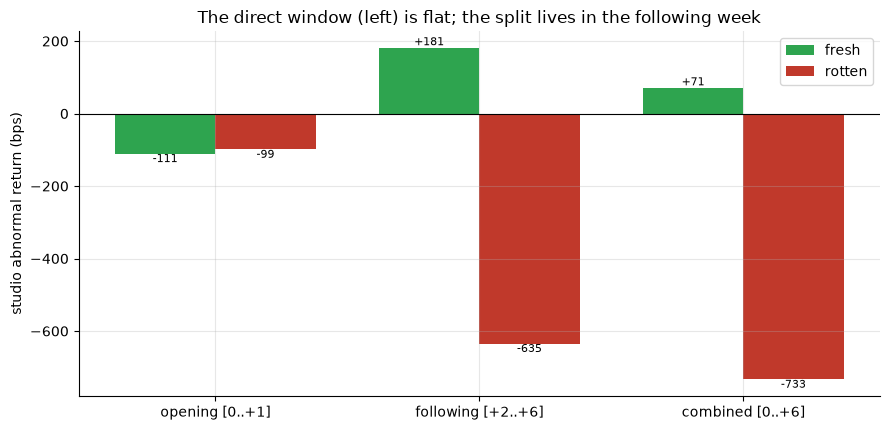

In [2]:
rows = []
if HAVE_REAL:
    for col, lab in [('ow_car','opening [0..+1]'), ('fw_car','following [+2..+6]'),
                     ('full_car','combined [0..+6]')]:
        ts = st.tier_stats(EVENTS, col=col)
        rows.append((lab, ts['fresh_bps'], ts['fresh_t'], ts['rotten_bps'],
                     ts['rotten_t'], ts['gap_bps'], ts['gap_welch_t']))
else:
    rows = [('opening [0..+1]', R['ow_fresh_bps'], R['ow_fresh_t'], R['ow_rotten_bps'],
             R['ow_rotten_t'], R['ow_gap_bps'], R['ow_gap_t']),
            ('following [+2..+6]', R['fw_fresh_bps'], R['fw_fresh_t'], R['fw_rotten_bps'],
             R['fw_rotten_t'], R['fw_gap_bps'], R['fw_gap_t']),
            ('combined [0..+6]', R['full_fresh_bps'], R['full_fresh_t'], R['full_rotten_bps'],
             R['full_rotten_t'], R['full_gap_bps'], R['full_gap_t'])]
df = pd.DataFrame(rows, columns=['window','fresh_bps','fresh_t','rotten_bps',
                                 'rotten_t','gap_bps','gap_welch_t']).set_index('window')
print(df.round(2).to_string())
fig, ax = plt.subplots(figsize=(9.0, 4.4))
x = np.arange(len(df)); w = 0.38
ax.bar(x - w/2, df['fresh_bps'], width=w, color=GREEN, label='fresh')
ax.bar(x + w/2, df['rotten_bps'], width=w, color=RED, label='rotten')
for i, (f, r) in enumerate(zip(df['fresh_bps'], df['rotten_bps'])):
    ax.annotate(f'{f:+.0f}', (i - w/2, f), ha='center', va='bottom' if f>=0 else 'top', fontsize=8)
    ax.annotate(f'{r:+.0f}', (i + w/2, r), ha='center', va='bottom' if r>=0 else 'top', fontsize=8)
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(df.index)
ax.set_ylabel('studio abnormal return (bps)')
ax.set_title('The direct window (left) is flat; the split lives in the following week')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: opening-weekend gap **-11.9 bps** (Welch *t* = -0.12) — H₁ rejected, wrong sign. Following-week gap **+816 bps** (Welch *t* = +2.58); the per-tier Newey-West *t*'s are +2.51 (fresh) and -2.09 (rotten). That clears the bar — so we interrogate it.

### 4b · The two placebos — split vs magnitude

The tier-label permutation (light in-notebook run; canonical 20k-draw *p* from `results.md`) against the random-date magnitude null.

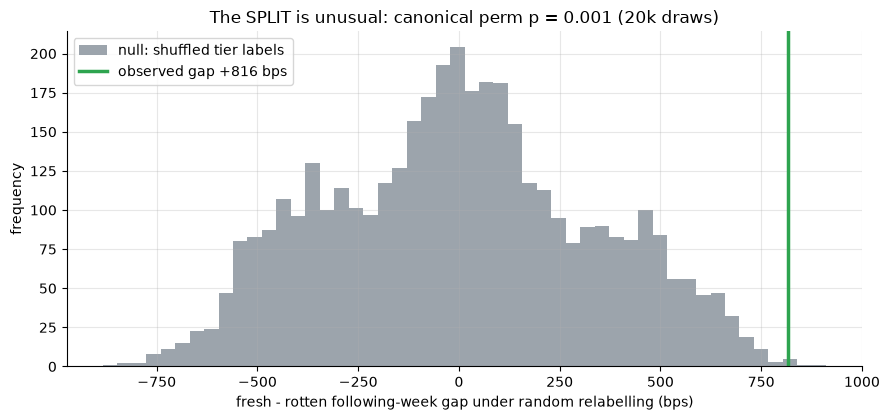

tier-label permutation: obs +816 bps vs null +0.6 (sd 328) -> p = 0.001
random-date (pooled MAGNITUDE): obs -206 bps -> two-sided p = 0.079  <-- a release week is NOT a big week


In [3]:
if HAVE_REAL:
    perm = st.permutation_placebo(EVENTS, col='fw_car', n_seeds=4, n_draws_per_seed=1000)
    obs, draws = perm['obs_bps'], perm['draws_bps']
else:
    obs = R['perm_obs_bps']
    rng = np.random.default_rng(847)
    draws = rng.normal(R['perm_mean_bps'], R['perm_sd_bps'], 4000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: shuffled tier labels')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed gap {obs:+.0f} bps')
ax.set_xlabel('fresh - rotten following-week gap under random relabelling (bps)')
ax.set_ylabel('frequency')
ax.set_title(f"The SPLIT is unusual: canonical perm p = {R['perm_p']:.3f} (20k draws)")
ax.legend(); plt.tight_layout(); plt.show()
print(f"tier-label permutation: obs {R['perm_obs_bps']:+.0f} bps vs null "
      f"{R['perm_mean_bps']:+.1f} (sd {R['perm_sd_bps']:.0f}) -> p = {R['perm_p']:.3f}")
print(f"random-date (pooled MAGNITUDE): obs {R['rand_obs_bps']:+.0f} bps -> "
      f"two-sided p = {R['rand_p']:.3f}  <-- a release week is NOT a big week")

> 💡 In plain words: the **split** sits far in the tail (*p* = 0.001) — fresh really did out-return rotten here. But the **pooled magnitude** is ordinary (*p* = 0.079): release weeks aren't bigger-moving than random weeks. A causal release effect would make *both* unusual. Only the split being unusual is what a **tier-correlated confound** looks like.

### 4c · Window-by-window — the effect is one transient blip

The fresh-minus-rotten gap swept from two weeks *before* the release to three weeks after. A genuine information effect would not be confined to a single post-release window.

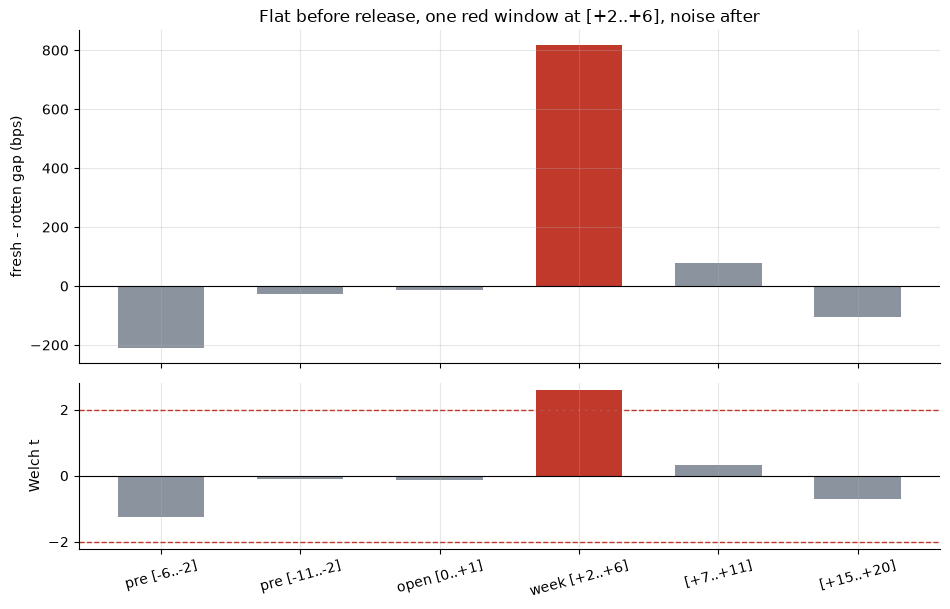

windows (gap bps, t): {'pre [-6..-2]': (-210, -1.26), 'pre [-11..-2]': (-26, -0.11), 'open [0..+1]': (-12, -0.12), 'week [+2..+6]': (816, 2.58), '[+7..+11]': (79, 0.33), '[+15..+20]': (-106, -0.7)}


In [4]:
labels = list(R['windows'].keys()); gaps = [R['windows'][k][0] for k in labels]
tvals = [R['windows'][k][1] for k in labels]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.6, 6.2), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
cols = [RED if abs(t) >= 2 else GREY for t in tvals]
a1.bar(labels, gaps, color=cols, width=.62); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('fresh - rotten gap (bps)')
a1.set_title('Flat before release, one red window at [+2..+6], noise after')
a2.bar(labels, tvals, color=cols, width=.62); a2.axhline(0, c='k', lw=.8)
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1)
a2.set_ylabel('Welch t'); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()
print('windows (gap bps, t):', {k: R['windows'][k] for k in labels})

> 💡 In plain words: the two **pre-release** windows are flat (no anticipation build-up), the gap is significant only at `[+2..+6]`, and it has decayed to noise by `[+7..+11]` and reverses by `[+15..+20]`. That is the shape of a look-elsewhere blip, not a durable reaction to news.

### 4d · The confound autopsy — Paramount, and "bad studios make bad films"

The two most extreme rotten weeks are not films; and trimming them does not kill the split — it *strengthens* it, because the gap is a broad ambient tilt.

In [5]:
if HAVE_REAL:
    inc = EVENTS[EVENTS['included']].copy(); inc['yr'] = inc['date'].str[:4].astype(int)
    def gap(d):
        f = d[d.tier=='fresh']['fw_car'].to_numpy(); r = d[d.tier=='rotten']['fw_car'].to_numpy()
        return (f.mean()-r.mean())*1e4, st.welch_t(f, r)
    g22, t22 = gap(inc[inc.yr<=2023]); g24, t24 = gap(inc[inc.yr>=2024])
    trim = inc[inc.fw_car.abs() < 0.15]; gt, tt = gap(trim)
    print(f'sub-era 2022-2023: gap {g22:+.0f} bps (t={t22:+.2f})')
    print(f'sub-era 2024-2025: gap {g24:+.0f} bps (t={t24:+.2f})')
    print(f'trim |CAR|>15% (drops {len(inc)-len(trim)}): gap {gt:+.0f} bps (t={tt:+.2f})')
    print('leave-one-studio-out Welch t:')
    for s in data.STUDIOS:
        _, t = gap(inc[inc.studio != s]); print(f'   drop {s:5s}: t = {t:+.2f}')
else:
    print(f"sub-era 2022-2023: gap {R['era_2223_gap']:+d} bps (t={R['era_2223_t']:+.2f})")
    print(f"sub-era 2024-2025: gap {R['era_2425_gap']:+d} bps (t={R['era_2425_t']:+.2f})")
    print(f"trim |CAR|>15%: gap {R['trim_gap']:+d} bps (t={R['trim_t']:+.2f})")
    print(f"leave-one-studio-out Welch t in [{R['loo_min_t']:.2f}, {R['loo_max_t']:.2f}]")
print('\nRobust to sub-era, LOO and trimming -> a real in-sample association.')
print('But: IF (PARA) and Bob Marley (PARA) rotten weeks = 2024 Skydance-takeover crashes.')
print('Declining studios (WBD, PARA) make BOTH worse films AND worse stocks -> selection.')

sub-era 2022-2023: gap +365 bps (t=+2.03)
sub-era 2024-2025: gap +1352 bps (t=+2.18)
trim |CAR|>15% (drops 3): gap +480 bps (t=+4.59)
leave-one-studio-out Welch t:
   drop DIS  : t = +2.45
   drop WBD  : t = +2.16
   drop PARA : t = +2.34
   drop CMCSA: t = +2.84
   drop NFLX : t = +2.42
   drop SONY : t = +2.34

Robust to sub-era, LOO and trimming -> a real in-sample association.
But: IF (PARA) and Bob Marley (PARA) rotten weeks = 2024 Skydance-takeover crashes.
Declining studios (WBD, PARA) make BOTH worse films AND worse stocks -> selection.


> 💡 In plain words: the split survives every robustness cut (sub-eras *t* = 2.03 / 2.18; leave-one-studio-out *t* ∈ [2.16, 2.84]; trimmed *t* = 4.59) — which is why it's **Weak, not None**. But it is a broad tilt tracking which studios were sinking, plus one literal takeover crash — which is why it's **Weak, not Real.** The tier is a proxy for the studio's fortunes, not a lever on the price.

### 4e · The timer — an honest cost check

Long the fresh studio / short the rotten studio over the following week; 2 × one-way cost × NAV per leg plus 50 bps/yr borrow on the short (rotten) legs.

In [6]:
if HAVE_REAL:
    rows = []
    for cb in (0.0, 5.0):
        tm = st.timer_stats(EVENTS, col='fw_car', cost_bps=cb)
        rows.append((cb, tm['gross_bps'], tm['net_bps'], tm['t_net']))
else:
    rows = [(cb, R['timer'][cb][0], R['timer'][cb][1], R['timer'][cb][2]) for cb in (0.0, 5.0)]
for cb, g, n, t in rows:
    print(f'cost {cb:>4.1f} bps/leg: gross {g:+.0f}  net {n:+.0f}  t(net) = {t:+.2f}')
print('\nSurvives naive costs (t = 2.50) — but it IS the fragile [+2..+6] split,')
print('window-selected and inflated by the Paramount crash. Fragile, not investable.')

cost  0.0 bps/leg: gross +397  net +396  t(net) = +2.56
cost  5.0 bps/leg: gross +397  net +386  t(net) = +2.50

Survives naive costs (t = 2.50) — but it IS the fragile [+2..+6] split,
window-selected and inflated by the Paramount crash. Fragile, not investable.


> 💡 In plain words: net **+386 bps/leg** at *t* = **2.50** — it "passes" only because it is the very same window-selected, non-causal gap, on 40 trades. A backtest artifact of a Weak signal is not a strategy.

### 4f · Faithful-engine & power control — we know the truth here

Synthetic paired (studio, benchmark) world with a TUNABLE planted tier drift on the following-week window. The null (edge = 0) is checked over 20 seeds.

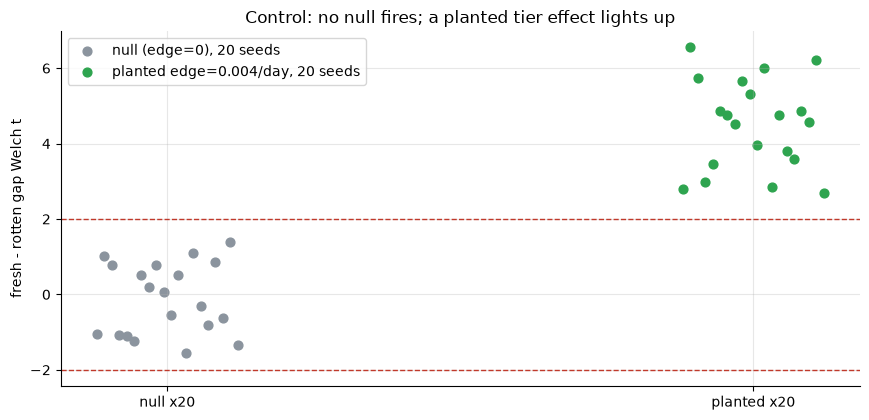

null: mean t = -0.12 (sd 0.95), |t|>=2 in 0/20
planted: mean t = +4.49 (sd 1.20), |t|>=2 in 20/20


In [7]:
null_t = np.array([st.synthetic_detect(edge=0.0, seed=847 + s)['gap_welch_t'] for s in range(20)])
plant_t = np.array([st.synthetic_detect(edge=0.004, seed=847 + s)['gap_welch_t'] for s in range(20)])
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_t, color=GREY, s=40,
           label='null (edge=0), 20 seeds')
ax.scatter(np.ones(20) + np.linspace(-.12, .12, 20), plant_t, color=GREEN, s=40,
           label='planted edge=0.004/day, 20 seeds')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x20', 'planted x20'])
ax.set_ylabel('fresh - rotten gap Welch t')
ax.set_title('Control: no null fires; a planted tier effect lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_t.mean():+.2f} (sd {null_t.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_t)>=2).sum()}/20')
print(f'planted: mean t = {plant_t.mean():+.2f} (sd {plant_t.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(plant_t)>=2).sum()}/20')

> 💡 In plain words: across 20 null worlds the detector averages *t* = -0.12 and **never** fires; a planted tier drift reads *t* = +4.49 and fires 20/20. The machinery is unbiased and faithful — and note its *modest* power at n≈20/tier, one more reason to treat a lone real-tape *t* = 2.58 with caution rather than as proof. *(A faithful-engine / power check only — never cited for the real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — opening-weekend gap **-11.9 bps** (Welch *t* = -0.12, wrong sign) on the direct window; a significant following-week gap **+816 bps** (Welch *t* = +2.58, perm *p* = 0.001, robust to sub-era & LOO) that fails the causal bar: no direct-window reaction, a single transient window, pooled magnitude ordinary (*p* = 0.079), implausible size, and a Paramount-takeover confound. A real in-sample association, **not** a review effect.
- **Tradability `FRAGILE`** — long-fresh/short-rotten net **+386 bps/leg** (*t* = 2.50) is a 40-trade artifact of the fragile window, not an edge.
- **"Does a flop tank the studio?" `OVERSTATED`** — the causal story isn't supported; a smaller, harder-to-attribute correlation is all that survives at n = 40.

## 6 · Going further

- **Attribution is the real limit.** A studio-fixed-effects design (a rotten film vs *that studio's own* average, absorbing the ambient decline) and a larger sample would separate "the review moved it" from "the studio was sinking anyway."
- **Cleaner instruments:** pure-play film names, or an intraday window around the review-embargo lift instead of a five-day close-to-close CAR that swallows unrelated corporate news (see the Paramount crash).
- **Dedup map:** [771-box-office-bomb](../../771-box-office-bomb/) (DIS flop event), [550-box-office-momentum](../../550-box-office-momentum/) (revenue momentum), [296-oscars-effect](../../296-oscars-effect/) (awards) and [552-app-store-rankings](../../552-app-store-rankings/) (tech product ratings) — same "public rating → stock" question, different signals.

*The reproducible core is offline and deterministic; frozen numbers in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*